# How to prepare Python plots with "double" axes (at both sides, or up and down)

### In some situations we may be interested in showing two different scales for the same (or multiple) dataset(s). Some examples:



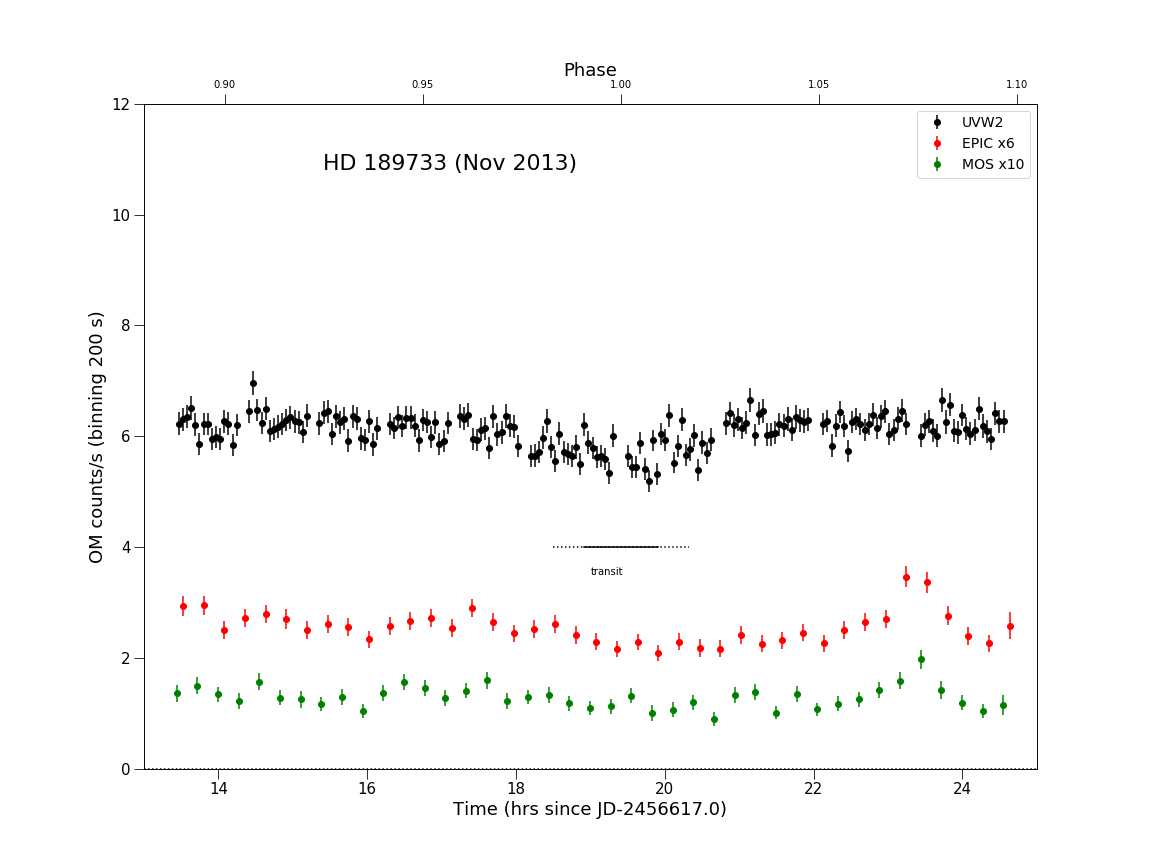

In [7]:
from IPython.display import Image
Image('curvaluz.png')

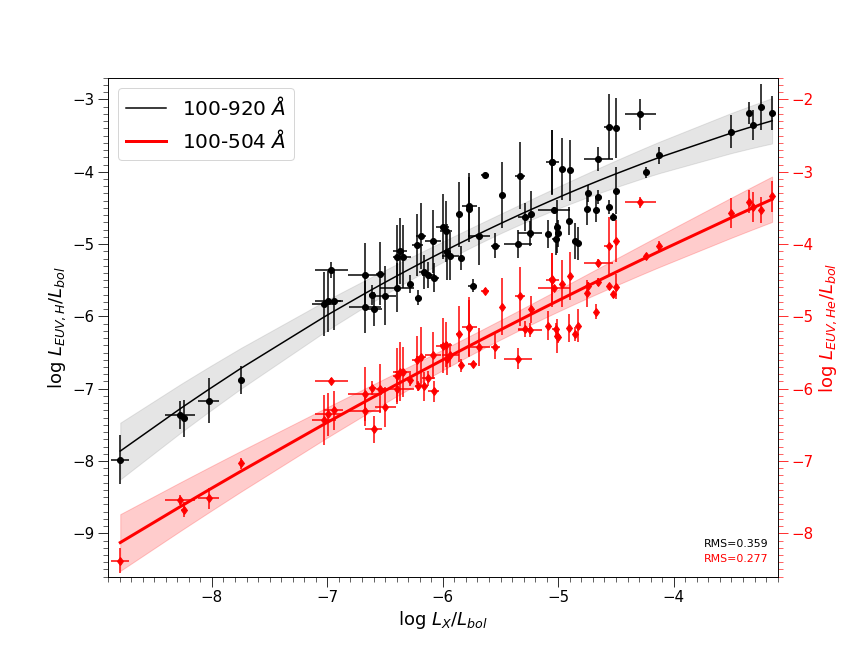

In [10]:
Image('xvseuvBol.png')

### Let's start with a simple example, a long term X-rays (coronal) light curve, with a sinusoidal fit overplotted:

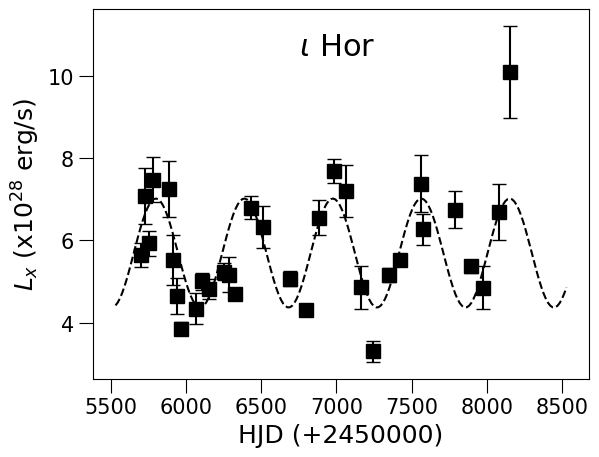

In [14]:
# A program to display the activity cycle data in chromosphere and corona of
# a star in the same plot.
# Applied to iota Hor (data from Sanz-Forcada et al. 2019, A&A 631, A45)
#
# Jorge Sanz (CAB), 2026-Apr-17
#
# Version 1: just the X-rays dataset
#
from astropy.table import Table
from pylab import *              #this includes matplotlib, and numpy as np

#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>   Variables
P=588.517   # period of the Lx data
xr1=[5530.,8300.]  # Axis limits of date (in days)
yr1=[2,12]         # Axis limits of Lx
#------------ parameters of a sinusoidal fit to Lx
B=[-1.3234,2.*pi/P,5.69504] 
nn=200  #number of points
dt=247.
#^^^^^^^^^^^^^^^^^^^^^^^^^^

# Reading x-rays
#----------------
coro=Table.read('tablaLx.dat',format='ascii')

# Prepare data for sinusoid plot vvvvvvvvvvvv
JD0=coro["Date"][0]+dt
tjd=arange(nn)*3000./(nn-1)+xr1[0]
yjd=B[0]*sin(B[1]*(tjd-JD0))+B[2]
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

#  Figura vvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
fig=figure()
x=fig.add_subplot(111)         #crea los ejes


xtitl='HJD (+2450000)'
ytitl='$L_x$ (x10$^{28}$ erg/s)'
tick_params(labelsize=15,which='major', length=10)
tick_params(which='minor', length=5)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
xlabel('HJD (+2450000)',size=18)
ylabel('$L_x$ (x10$^{28}$ erg/s)',size=18)

ax.set_xlim(xr1)
ax.set_ylim(yr1)
text(6750,10.5,r"$\iota$ Hor",size=22)
errorbar(coro["Date"],coro["Lx"],yerr=coro["eLx"],fmt='ks',ms=10,capsize=5)
plot(tjd,yjd,'k--')

show()
#  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

### Now let's add an upper axis with the time in years, using "twinx"

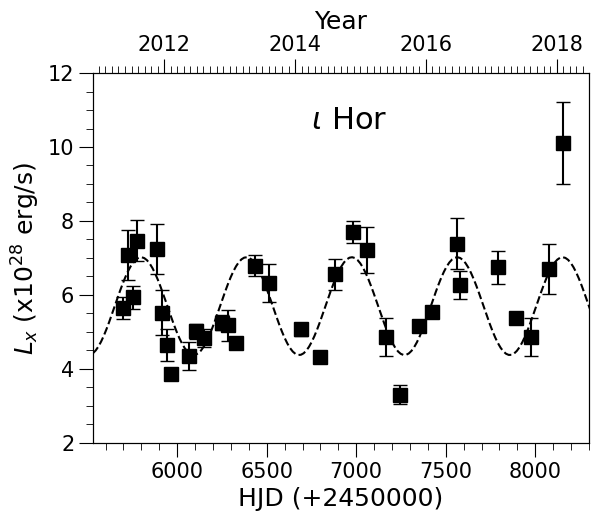

In [1]:
# A program to display the activity cycle data in chromosphere and corona of
# a star in the same plot.
# Applied to iota Hor (data from Sanz-Forcada et al. 2019, A&A 631, A45)
#
# Jorge Sanz (CAB), 2026-Apr-17
#
# Version 1: just the X-rays dataset
# Version 2: adding an upper axis with Year instead of days (double axes)
#
from astropy.table import Table
from pylab import *              #this includes matplotlib, and numpy as np
from astropy.time import Time

#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>   Variables
P=588.517   # period of the Lx data
xr1=[5530.,8300.]  # Axis limits of date (in days)
yr1=[2,12]         # Axis limits of Lx
#------------ parameters of a sinusoidal fit to Lx
B=[-1.3234,2.*pi/P,5.69504] 
nn=200  #number of points
dt=247.
#^^^^^^^^^^^^^^^^^^^^^^^^^^
xr2=zeros(2,float)
for i in range (2):
    fecha=Time((xr1[i]+2450000.),format='jd').decimalyear
    xr2[i]=fecha   # Axis limits of date (in yr)

# Reading x-rays data and S-index data
#--------------------------------------
coro=Table.read('tablaLx.dat',format='ascii')

# Prepare data for sinusoid plot vvvvvvvvvvvv
JD0=coro["Date"][0]+dt
tjd=arange(nn)*3000./(nn-1)+xr1[0]
yjd=B[0]*sin(B[1]*(tjd-JD0))+B[2]
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

#  Figura vvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
fig=figure()
ax=fig.add_subplot(111)         #crea los ejes

xtitl='HJD (+2450000)'
ytitl='$L_x$ (x10$^{28}$ erg/s)'
tick_params(labelsize=15,which='major', length=10)
tick_params(which='minor', length=5)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
xlabel('HJD (+2450000)',size=18)
ylabel('$L_x$ (x10$^{28}$ erg/s)',size=18)

ax.set_xlim(xr1)
ax.set_ylim(yr1)
text(6750,10.5,r"$\iota$ Hor",size=22)
errorbar(coro["Date"],coro["Lx"],yerr=coro["eLx"],fmt='ks',ms=10,capsize=5)
plot(tjd,yjd,'k--')

#   Uppser axis (must be AFTER the plot is drawn)
ax_year=ax.twiny()
ax_year.set_xlabel('Year',size=18)
ax_year.set_xlim(xr2)
ax_year.xaxis.set_minor_locator(MultipleLocator(0.1))
tick_params(labelsize=15,length=10)  #this has to be done again for new axes
tick_params(which='minor', length=5)

show()
#  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


### We add now a second dataset of a variable ($S$ = chromospheric S-index) that uses a different scale, thus we need a different axis. In this case we need a more complex transformation of the type:
###  $ S' = a\, S + b$, where $a = \frac{\Delta L_x}{\Delta S}$, and $b=\overline{L_x}  - a\, \overline{S}$
### ($\overline{L_X}$ and $\overline{S}$ refer to the central point of the ranges covered in $L_x$ and $S$ axes).

In [15]:
#! /usr/bin/python
# -*- coding: cp1252 -*-
# ejemplo3.py
#-----------------
#
# A program to display the activity cycle data in chromosphere and corona of
# a star in the same plot.
# Applied to iota Hor (data from Sanz-Forcada et al. 2019, A&A 631, A45)
#
# Jorge Sanz (CAB), 2026-Apr-17
#
# Version 1: just the X-rays dataset
# Version 2: adding an upper axis with Year instead of days (double axes)
# Version 3: adding a second dataset, with its own axis
#
from astropy.table import Table
from pylab import *              #this includes matplotlib, and numpy as np
from astropy.time import Time

#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>   Variables
P=588.517   # period of the Lx data
xr1=[5530.,8300.]  # Axis limits of date (in days)
yr1=[2,12]         # Axis limits of Lx
yr2=[0.20,0.30]    # Axis limits of S-index
#------------ parameters of a sinusoidal fit to Lx
B=[-1.3234,2.*pi/P,5.69504] 
nn=200  #number of points
dt=247.
#------------ plotting variables
printing='png'     #'' for screen, or 'png' or 'eps'
plfile='ejemplo3'
#^^^^^^^^^^^^^^^^^^^^^^^^^^
xr2=zeros(2,float)
for i in range (2):
    fecha=Time((xr1[i]+2450000.),format='jd').decimalyear
    xr2[i]=fecha   # Axis limits of date (in yr)

# Reading x-rays data and S-index data
#--------------------------------------
coro=Table.read('tablaLx.dat',format='ascii')
chromo=Table.read('tablaSindex.dat',format='ascii')
s,es=chromo["S-index"],chromo["eS"]

# Prepare data for sinusoid plot vvvvvvvvvvvv
JD0=coro["Date"][0]+dt
tjd=arange(nn)*3000./(nn-1)+xr1[0]
yjd=B[0]*sin(B[1]*(tjd-JD0))+B[2]
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# Scale to transform S-index to the scale of Lx
#------------------------------------------------
# Transformation in S-index: S'=a S + b
aS=(yr1[0]-yr1[1]) / (yr2[0]-yr2[1])
bS=0.5*(yr1[0]+yr1[1] - aS * (yr2[0]+yr2[1]))
s=aS * s + bS
es=es*aS


#  Figura vvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
if printing == '':
    fig=figure()
else:
    fig=figure(figsize=(16,8),dpi=80)
ax=fig.add_subplot(111)         #crea los ejes


xtitl='HJD (+2450000)'
ytitl='$L_x$ (x10$^{28}$ erg/s)'
tick_params(labelsize=15,which='major', length=10)
tick_params(which='minor', length=5)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
xlabel('HJD (+2450000)',size=18)
ylabel('$L_x$ (x10$^{28}$ erg/s)',size=18)

ax.set_xlim(xr1)
ax.set_ylim(yr1)
text(6750,10.5,r"$\iota$ Hor",size=22)
errorbar(coro["Date"],coro["Lx"],yerr=coro["eLx"],fmt='ks',ms=10,capsize=5)
errorbar(chromo["Date"],s,yerr=es,fmt='ro',ms=10,fillstyle='none')#,\
#    it is better to put the labels in plot than in errorbar:
plot(coro["Date"],coro["Lx"],'ks',label='Corona (X-rays)',ms=10)
plot(chromo["Date"],s,'ro',label='Chromosphere (S-index)',ms=10,fillstyle='none')
plot(tjd,yjd,'k--')
legend(fontsize=14)

# Axis in the right side (must be AFTER the plot is drawn)
ax_sindex=ax.twinx()
ax_sindex.set_ylabel('Mount Wilson S-index',size=18)
ax_sindex.set_ylim(yr2)
ax_sindex.yaxis.set_minor_locator(MultipleLocator(0.005))
tick_params(labelsize=15,length=10)  #this has to be done again for new axes
tick_params(which='minor', length=5)

#   Uppser axis
ax_year=ax.twiny()
ax_year.set_xlabel('Year',size=18)
ax_year.set_xlim(xr2)
ax_year.xaxis.set_minor_locator(MultipleLocator(0.1))
tick_params(labelsize=15,length=10)
tick_params(which='minor', length=5)

if printing == '': show()
else: savefig(plfile+'.'+printing,dpi=80)
close('all')
#  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

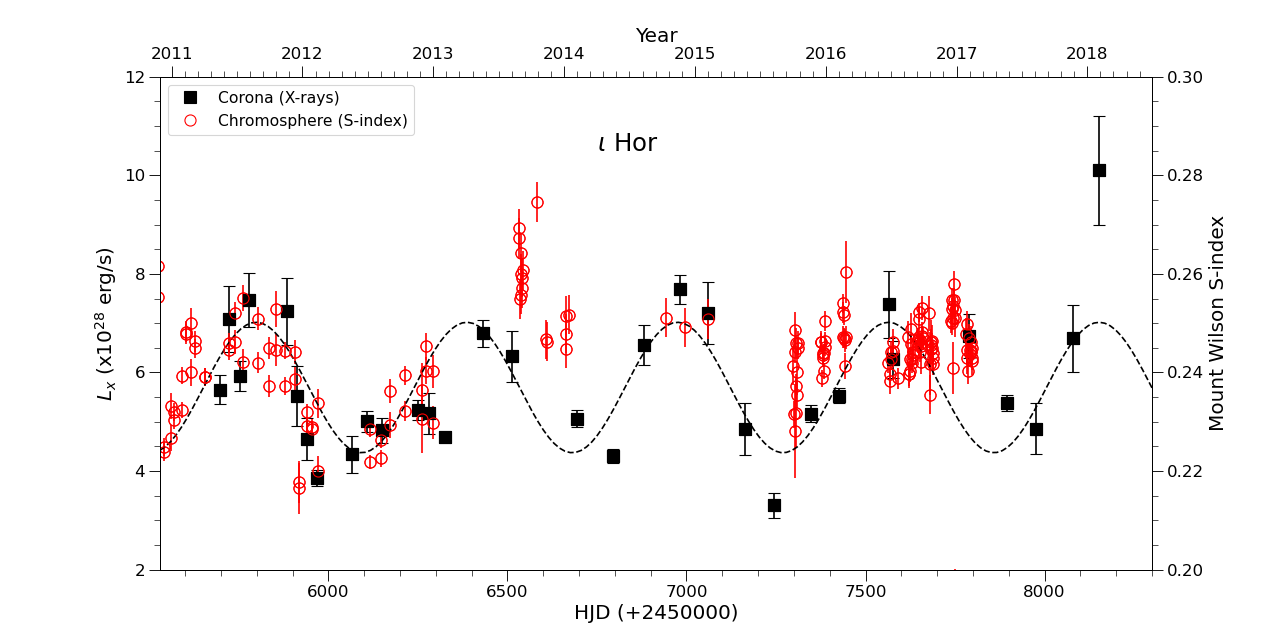

In [16]:
Image('ejemplo3.png')

### For a better display we can change also the color of the new axis (change the title, the numbers, and the tick marks)

In [17]:
# A program to display the activity cycle data in chromosphere and corona of
# a star in the same plot.
# Applied to iota Hor (data from Sanz-Forcada et al. 2019, A&A 631, A45)
#
# Jorge Sanz (CAB), 2026-Apr-17
#
# Version 1: just the X-rays dataset
# Version 2: adding an upper axis with Year instead of days (double axes)
# Version 3: adding a second dataset, with its own axis
# Version 4: change color of right-side axis to use same as the second dataset
#
from astropy.table import Table
from pylab import *              #this includes matplotlib, and numpy as np
from astropy.time import Time

#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>   Variables
P=588.517   # period of the Lx data
xr1=[5530.,8300.]  # Axis limits of date (in days)
yr1=[2,12]         # Axis limits of Lx
yr2=[0.20,0.30]    # Axis limits of S-index
#------------ parameters of a sinusoidal fit to Lx
B=[-1.3234,2.*pi/P,5.69504] 
nn=200  #number of points
dt=247.
#------------ plotting variables
printing='png'     #'' for screen, or 'png' or 'eps'
plfile='ejemplo4'
#^^^^^^^^^^^^^^^^^^^^^^^^^^
xr2=zeros(2,float)
for i in range (2):
    fecha=Time((xr1[i]+2450000.),format='jd').decimalyear
    xr2[i]=fecha   # Axis limits of date (in yr)

# Reading x-rays data and S-index data
#--------------------------------------
coro=Table.read('tablaLx.dat',format='ascii')
chromo=Table.read('tablaSindex.dat',format='ascii')
s,es=chromo["S-index"],chromo["eS"]

# Prepare data for sinusoid plot vvvvvvvvvvvv
JD0=coro["Date"][0]+dt
tjd=arange(nn)*3000./(nn-1)+xr1[0]
yjd=B[0]*sin(B[1]*(tjd-JD0))+B[2]
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# Scale to transform S-index to the scale of Lx
#------------------------------------------------
# Transformation in S-index: S'=a S + b
aS=(yr1[1]-yr1[0]) / (yr2[1]-yr2[0])
bS=0.5*(yr1[0]+yr1[1] - aS * (yr2[0]+yr2[1]))
s=aS * s + bS
es=es*aS

#  Figura vvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
if printing == '':
    fig=figure()
else:
    fig=figure(figsize=(16,8),dpi=80)
ax=fig.add_subplot(111)         #crea los ejes


xtitl='HJD (+2450000)'
ytitl='$L_x$ (x10$^{28}$ erg/s)'
tick_params(labelsize=15,which='major', length=10)
tick_params(which='minor', length=5)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
xlabel('HJD (+2450000)',size=18)
ylabel('$L_x$ (x10$^{28}$ erg/s)',size=18)

ax.set_xlim(xr1)
ax.set_ylim(yr1)
text(6750,10.5,r"$\iota$ Hor",size=22)
errorbar(coro["Date"],coro["Lx"],yerr=coro["eLx"],fmt='ks',ms=10,capsize=5)
errorbar(chromo["Date"],s,yerr=es,fmt='ro',ms=10,fillstyle='none')#,\
#    it is better to put the labels in plot than in errorbar:
plot(coro["Date"],coro["Lx"],'ks',label='Corona (X-rays)',ms=10)
plot(chromo["Date"],s,'ro',label='Chromosphere (S-index)',ms=10,fillstyle='none')
plot(tjd,yjd,'k--')
legend(fontsize=14)

# Axis in the right side (must be AFTER the plot is drawn)
ax_sindex=ax.twinx()
ax_sindex.set_ylabel('Mount Wilson S-index',size=18,color='r')
ax_sindex.set_ylim(yr2)
ax_sindex.yaxis.set_minor_locator(MultipleLocator(0.005))
yticks(size=15,color='r')                          # Note the red color
tick_params(labelsize=15,length=10,color='red')  
tick_params(which='minor', length=5,color='red')

#   Uppser axis
ax_year=ax.twiny()
ax_year.set_xlabel('Year',size=18)
ax_year.set_xlim(xr2)
ax_year.xaxis.set_minor_locator(MultipleLocator(0.1))
tick_params(labelsize=15,length=10)
tick_params(which='minor', length=5)

if printing == '': show()
else: savefig(plfile+'.'+printing,dpi=80)
close('all')
#  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

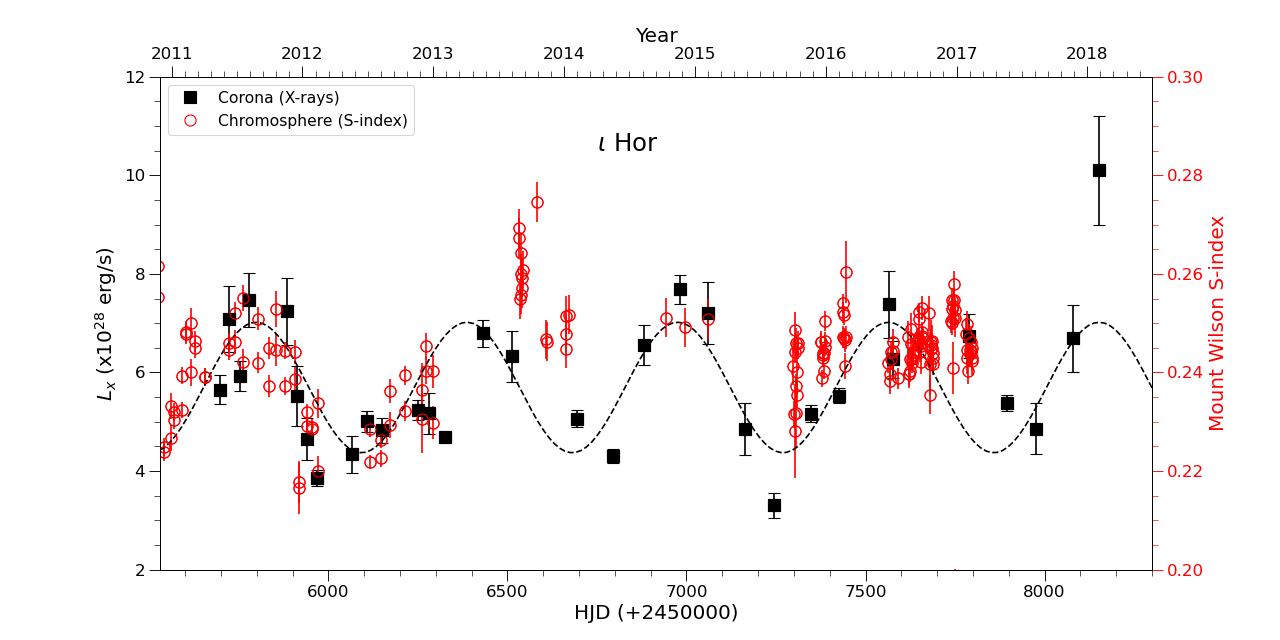

In [18]:
Image('ejemplo4.png')

## Bonus track: how to do not one, but two legend boxes in the plot. Use "add_artist"

In [19]:
# A program to display the activity cycle data in chromosphere and corona of
# a star in the same plot.
# Applied to iota Hor (data from Sanz-Forcada et al. 2019, A&A 631, A45)
#
# Jorge Sanz (CAB), 2026-Apr-17
#
# Version 1: just the X-rays dataset
# Version 2: adding an upper axis with Year instead of days (double axes)
# Version 3: adding a second dataset, with its own axis
# Version 4: change color of right-side axis to use same as the second dataset
# Version 5: show how to add a second legend to the plot
#
from astropy.table import Table
from pylab import *              #this includes matplotlib, and numpy as np
from astropy.time import Time

#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>   Variables
P=588.517   # period of the Lx data
xr1=[5530.,8300.]  # Axis limits of date (in days)
yr1=[2,12]         # Axis limits of Lx
yr2=[0.20,0.30]    # Axis limits of S-index
#------------ parameters of a sinusoidal fit to Lx
B=[-1.3234,2.*pi/P,5.69504] 
nn=200  #number of points
dt=247.
#------------ plotting variables
printing='png'     #'' for screen, or 'png' or 'eps'
plfile='ejemplo5'
#^^^^^^^^^^^^^^^^^^^^^^^^^^
xr2=zeros(2,float)
for i in range (2):
    fecha=Time((xr1[i]+2450000.),format='jd').decimalyear
    xr2[i]=fecha   # Axis limits of date (in yr)

# Reading x-rays data and S-index data
#--------------------------------------
coro=Table.read('tablaLx.dat',format='ascii')
chromo=Table.read('tablaSindex.dat',format='ascii')
s,es=chromo["S-index"],chromo["eS"]

# Prepare data for sinusoid plot vvvvvvvvvvvv
JD0=coro["Date"][0]+dt
tjd=arange(nn)*3000./(nn-1)+xr1[0]
yjd=B[0]*sin(B[1]*(tjd-JD0))+B[2]
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# Scale to transform S-index to the scale of Lx
#------------------------------------------------
# Transformation in S-index: S' = a S + b
aS=(yr1[0]-yr1[1]) / (yr2[0]-yr2[1])
bS=0.5*(yr1[0]+yr1[1] - aS * (yr2[0]+yr2[1]))
s=aS * s + bS
es=es*aS


#  Figura vvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
if printing == '':
    fig=figure()
else:
    fig=figure(figsize=(16,8),dpi=80)
ax=fig.add_subplot(111)         #crea los ejes


xtitl='HJD (+2450000)'
ytitl='$L_x$ (x10$^{28}$ erg/s)'
tick_params(labelsize=15,which='major', length=10)
tick_params(which='minor', length=5)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
xlabel('HJD (+2450000)',size=18)
ylabel('$L_x$ (x10$^{28}$ erg/s)',size=18)

ax.set_xlim(xr1)
ax.set_ylim(yr1)
text(6750,10.5,r"$\iota$ Hor",size=22)
errorbar(coro["Date"],coro["Lx"],yerr=coro["eLx"],fmt='ks',ms=10,capsize=5)
errorbar(chromo["Date"],s,yerr=es,fmt='ro',ms=10,fillstyle='none')#,\
plot(coro["Date"],coro["Lx"],'ks',ms=10)
plot(chromo["Date"],s,'ro',ms=10,fillstyle='none')

#  we have to define the legend in the same order that the data were plotted:
main_legend=legend(['Corona (X-rays)','Chromosphere (S-index)'],\
                   fontsize=14,loc='upper left')
ax.add_artist(main_legend)

plot(tjd,yjd,'k--',label='Fit to coronal cycle')
legend(fontsize=14,loc='lower right')   # second legend



# Axis in the right side (must be AFTER the plot is drawn)
ax_sindex=ax.twinx()
ax_sindex.set_ylabel('Mount Wilson S-index',size=18,color='r')
ax_sindex.set_ylim(yr2)
ax_sindex.yaxis.set_minor_locator(MultipleLocator(0.005))
yticks(size=15,color='r')                          # Note the red color
tick_params(labelsize=15,length=10,color='red')  
tick_params(which='minor', length=5,color='red')

#   Uppser axis
ax_year=ax.twiny()
ax_year.set_xlabel('Year',size=18)
ax_year.set_xlim(xr2)
ax_year.xaxis.set_minor_locator(MultipleLocator(0.1))
tick_params(labelsize=15,length=10)
tick_params(which='minor', length=5)

if printing == '': show()
else: savefig(plfile+'.'+printing,dpi=80)
close('all')
#  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

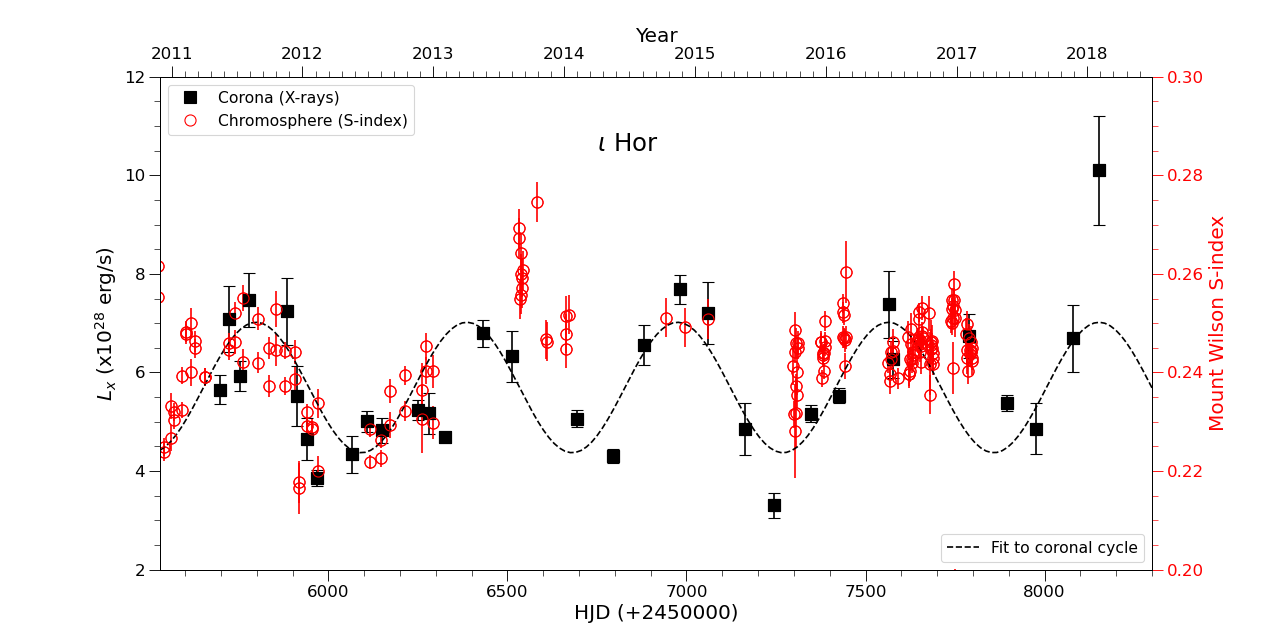

In [20]:
Image('ejemplo5.png')